<a href="https://colab.research.google.com/github/osergioribeirof/Python/blob/main/GammaFlip_Interativo_US.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

📅 Tentando parsear data: '8 de outubro de 2025'
✓ Data parseada com sucesso: 08/10/2025

📊 Dados carregados: 4202 opções
💰 Total Gamma Exposure: $47.86 Bn
✓ Gráfico 1 salvo: gamma_chart1.png


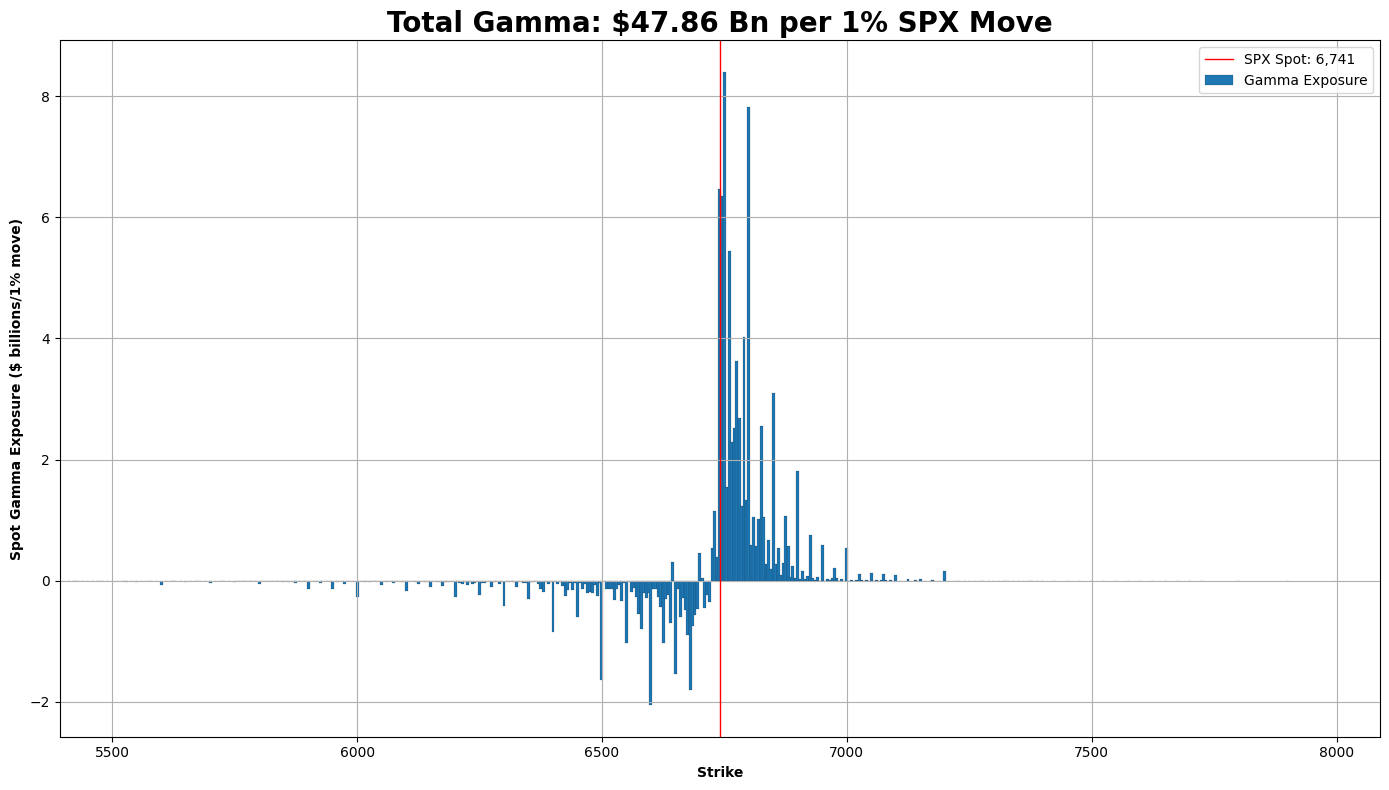

✓ Gráfico 2 salvo: gamma_chart2.png


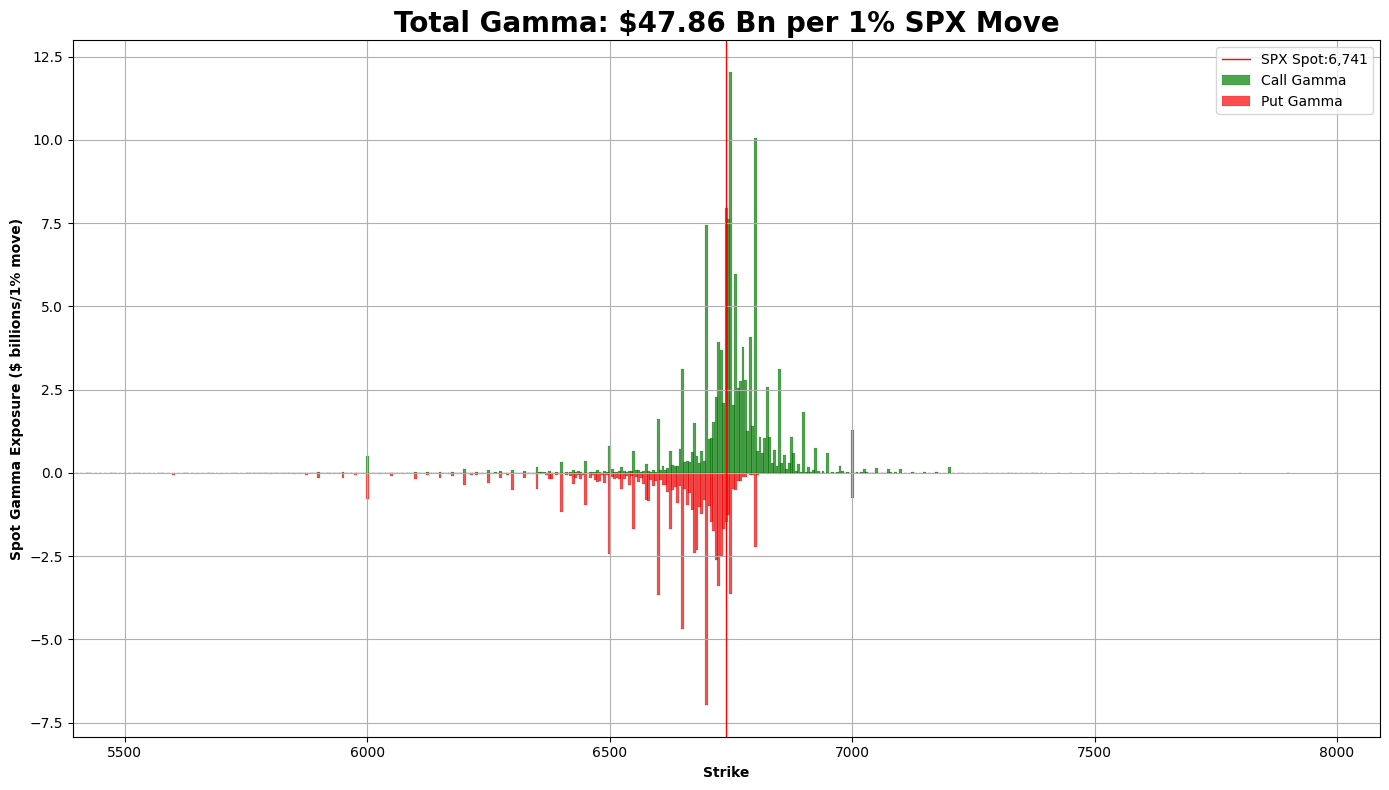


🔄 Calculando perfil de gamma...
  Progresso: 0/60
  Progresso: 10/60
  Progresso: 20/60
  Progresso: 30/60
  Progresso: 40/60
  Progresso: 50/60
✓ Perfil de gamma calculado
🎯 Zero Gamma Level: 6,702.53
✓ Gráfico 3 salvo: gamma_chart3.png


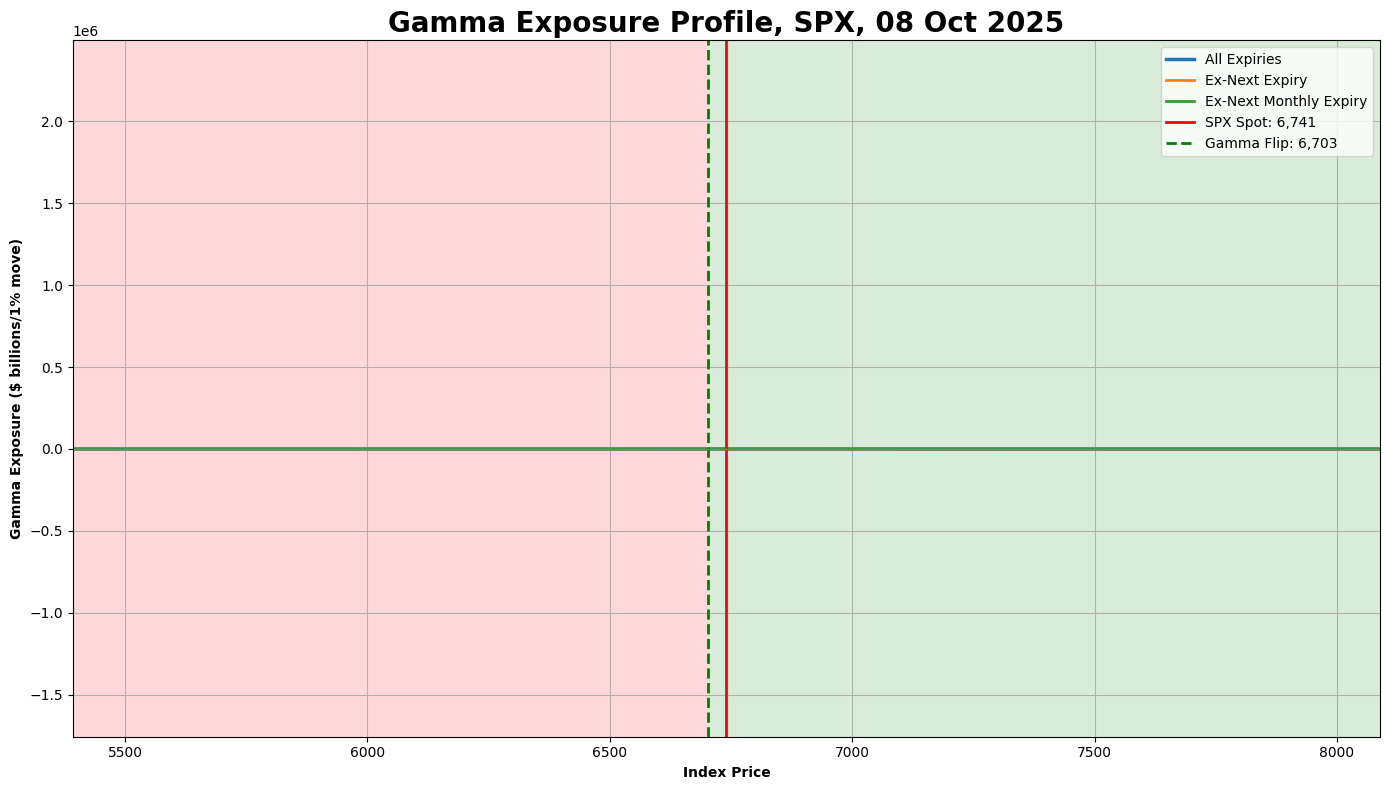


✅ ANÁLISE CONCLUÍDA!

📊 Resumo:
   Spot Price: 6,740.69
   Total Gamma: $47.86 Bn
   Zero Gamma: 6,702.53
   Distância do Zero: 38.16
   Regime: Long Gamma (Estável)

📁 Arquivos gerados:
   • gamma_chart1.png
   • gamma_chart2.png
   • gamma_chart3.png


In [ ]:
import pandas as pd
import numpy as np
import scipy
from scipy.stats import norm
import matplotlib.pyplot as plt
from datetime import datetime, timedelta, date
import locale
import re

pd.options.display.float_format = '{:,.4f}'.format

# Inputs and Parameters
filename = 'spx_quotedata.csv'

# Black-Scholes European-Options Gamma
def calcGammaEx(S, K, vol, T, r, q, optType, OI):
    if T == 0 or vol == 0:
        return 0

    dp = (np.log(S/K) + (r - q + 0.5*vol**2)*T) / (vol*np.sqrt(T))
    dm = dp - vol*np.sqrt(T)

    if optType == 'call':
        gamma = np.exp(-q*T) * norm.pdf(dp) / (S * vol * np.sqrt(T))
        return OI * 100 * S * S * 0.01 * gamma
    else: # Gamma is same for calls and puts. This is just to cross-check
        gamma = K * np.exp(-r*T) * norm.pdf(dm) / (S * S * vol * np.sqrt(T))
        return OI * 100 * S * S * 0.01 * gamma

def isThirdFriday(d):
    return d.weekday() == 4 and 15 <= d.day <= 21


def parse_portuguese_date(date_string):
    """
    Parse dates in Portuguese format: "8 de outubro de 2025"
    """
    # Mapeamento de meses em português
    meses_pt = {
        'janeiro': 1, 'jan': 1,
        'fevereiro': 2, 'fev': 2,
        'março': 3, 'mar': 3,
        'abril': 4, 'abr': 4,
        'maio': 5, 'mai': 5,
        'junho': 6, 'jun': 6,
        'julho': 7, 'jul': 7,
        'agosto': 8, 'ago': 8,
        'setembro': 9, 'set': 9,
        'outubro': 10, 'out': 10,
        'novembro': 11, 'nov': 11,
        'dezembro': 12, 'dez': 12
    }

    # Limpar string
    date_string = date_string.strip().lower()

    # Pattern: "8 de outubro de 2025" ou "8 outubro 2025"
    pattern = r'(\d{1,2})\s+(?:de\s+)?(\w+)\s+(?:de\s+)?(\d{4})'
    match = re.match(pattern, date_string)

    if match:
        day = int(match.group(1))
        month_str = match.group(2)
        year = int(match.group(3))

        # Buscar mês
        month = meses_pt.get(month_str)
        if month:
            return datetime(year, month, day)

    return None


def parse_date_flexible(date_string):
    """
    Tenta parsear data em vários formatos (inglês e português)
    """
    # Lista de formatos para tentar
    date_formats = [
        '%B %d, %Y',        # October 8, 2025
        '%d %B, %Y',        # 8 October, 2025
        '%d/%m/%Y',         # 08/10/2025
        '%m/%d/%Y',         # 10/08/2025
        '%Y-%m-%d',         # 2025-10-08
        '%d-%m-%Y',         # 08-10-2025
        '%d %B %Y',         # 8 October 2025
        '%B %d %Y',         # October 8 2025
    ]

    # Primeiro tenta português
    pt_date = parse_portuguese_date(date_string)
    if pt_date:
        return pt_date

    # Depois tenta formatos padrão
    for fmt in date_formats:
        try:
            return datetime.strptime(date_string, fmt)
        except ValueError:
            continue

    return None


# This assumes the CBOE file format hasn't been edited, i.e. table begins at line 4
optionsFile = open(filename)
optionsFileData = optionsFile.readlines()
optionsFile.close()

# Get SPX Spot
spotLine = optionsFileData[1]
spotPrice = float(spotLine.split('Last:')[1].split(',')[0])
fromStrike = 0.8 * spotPrice
toStrike = 1.2 * spotPrice

# Get Today's Date
dateLine = optionsFileData[2]
todayDate_str = dateLine.split('Date: ')[1].split(';')[0].strip()

# Extract only the date part before parsing
if ' às ' in todayDate_str:
    date_part_str = todayDate_str.split(' às ')[0]
elif ' at ' in todayDate_str:
    date_part_str = todayDate_str.split(' at ')[0]
else:
    date_part_str = todayDate_str

print(f"📅 Tentando parsear data: '{date_part_str}'")

# Tentar parsear com função flexível
todayDate = parse_date_flexible(date_part_str)

if todayDate is None:
    print(f"⚠️  Não foi possível parsear automaticamente.")
    print(f"   String original: '{date_part_str}'")
    print(f"\n🔧 Usando data atual como fallback...")
    todayDate = datetime.now()
else:
    print(f"✓ Data parseada com sucesso: {todayDate.strftime('%d/%m/%Y')}")

# Get SPX Options Data
df = pd.read_csv(filename, sep=",", header=None, skiprows=4)
df.columns = ['ExpirationDate','Calls','CallLastSale','CallNet','CallBid','CallAsk','CallVol',
              'CallIV','CallDelta','CallGamma','CallOpenInt','StrikePrice','Puts','PutLastSale',
              'PutNet','PutBid','PutAsk','PutVol','PutIV','PutDelta','PutGamma','PutOpenInt']

df['ExpirationDate'] = pd.to_datetime(df['ExpirationDate'], format='%a %b %d %Y')
df['ExpirationDate'] = df['ExpirationDate'] + timedelta(hours=16)
df['StrikePrice'] = df['StrikePrice'].astype(float)
df['CallIV'] = df['CallIV'].astype(float)
df['PutIV'] = df['PutIV'].astype(float)
df['CallGamma'] = df['CallGamma'].astype(float)
df['PutGamma'] = df['PutGamma'].astype(float)
df['CallOpenInt'] = df['CallOpenInt'].astype(float)
df['PutOpenInt'] = df['PutOpenInt'].astype(float)

print(f"\n📊 Dados carregados: {len(df)} opções")

# ---=== CALCULATE SPOT GAMMA ===---
# Gamma Exposure = Unit Gamma * Open Interest * Contract Size * Spot Price
# To further convert into 'per 1% move' quantity, multiply by 1% of spotPrice
df['CallGEX'] = df['CallGamma'] * df['CallOpenInt'] * 100 * spotPrice * spotPrice * 0.01
df['PutGEX'] = df['PutGamma'] * df['PutOpenInt'] * 100 * spotPrice * spotPrice * 0.01 * -1

df['TotalGamma'] = (df.CallGEX + df.PutGEX) / 10**9
dfAgg = df.groupby(['StrikePrice']).sum(numeric_only=True)
strikes = dfAgg.index.values

print(f"💰 Total Gamma Exposure: ${df['TotalGamma'].sum():.2f} Bn")

# Chart 1: Absolute Gamma Exposure
plt.figure(figsize=(14, 8))
plt.grid()
plt.bar(strikes, dfAgg['TotalGamma'].to_numpy(), width=6, linewidth=0.1, edgecolor='k', label="Gamma Exposure")
plt.xlim([fromStrike, toStrike])
chartTitle = "Total Gamma: $" + str("{:.2f}".format(df['TotalGamma'].sum())) + " Bn per 1% SPX Move"
plt.title(chartTitle, fontweight="bold", fontsize=20)
plt.xlabel('Strike', fontweight="bold")
plt.ylabel('Spot Gamma Exposure ($ billions/1% move)', fontweight="bold")
plt.axvline(x=spotPrice, color='r', lw=1, label="SPX Spot: " + str("{:,.0f}".format(spotPrice)))
plt.legend()
plt.tight_layout()
plt.savefig('gamma_chart1.png', dpi=150)
print("✓ Gráfico 1 salvo: gamma_chart1.png")
plt.show()

# Chart 2: Absolute Gamma Exposure by Calls and Puts
plt.figure(figsize=(14, 8))
plt.grid()
plt.bar(strikes, dfAgg['CallGEX'].to_numpy() / 10**9, width=6, linewidth=0.1, edgecolor='k', label="Call Gamma", color='green', alpha=0.7)
plt.bar(strikes, dfAgg['PutGEX'].to_numpy() / 10**9, width=6, linewidth=0.1, edgecolor='k', label="Put Gamma", color='red', alpha=0.7)
plt.xlim([fromStrike, toStrike])
chartTitle = "Total Gamma: $" + str("{:.2f}".format(df['TotalGamma'].sum())) + " Bn per 1% SPX Move"
plt.title(chartTitle, fontweight="bold", fontsize=20)
plt.xlabel('Strike', fontweight="bold")
plt.ylabel('Spot Gamma Exposure ($ billions/1% move)', fontweight="bold")
plt.axvline(x=spotPrice, color='r', lw=1, label="SPX Spot:" + str("{:,.0f}".format(spotPrice)))
plt.legend()
plt.tight_layout()
plt.savefig('gamma_chart2.png', dpi=150)
print("✓ Gráfico 2 salvo: gamma_chart2.png")
plt.show()

# ---=== CALCULATE GAMMA PROFILE ===---
print("\n🔄 Calculando perfil de gamma...")
levels = np.linspace(fromStrike, toStrike, 60)

# For 0DTE options, I'm setting DTE = 1 day, otherwise they get excluded
df['daysTillExp'] = [1/262 if (np.busday_count(todayDate.date(), x.date())) == 0 \
                           else np.busday_count(todayDate.date(), x.date())/262 for x in df.ExpirationDate]

nextExpiry = df['ExpirationDate'].min()

df['IsThirdFriday'] = [isThirdFriday(x) for x in df.ExpirationDate]
thirdFridays = df.loc[df['IsThirdFriday'] == True]
nextMonthlyExp = thirdFridays['ExpirationDate'].min()

totalGamma = []
totalGammaExNext = []
totalGammaExFri = []

# For each spot level, calc gamma exposure at that point
for i, level in enumerate(levels):
    if i % 10 == 0:
        print(f"  Progresso: {i}/{len(levels)}")

    df['callGammaEx'] = df.apply(lambda row : calcGammaEx(level, row['StrikePrice'], row['CallIV'],
                                                          row['daysTillExp'], 0, 0, "call", row['CallOpenInt']), axis = 1)

    df['putGammaEx'] = df.apply(lambda row : calcGammaEx(level, row['StrikePrice'], row['PutIV'],
                                                         row['daysTillExp'], 0, 0, "put", row['PutOpenInt']), axis = 1)

    totalGamma.append(df['callGammaEx'].sum() - df['putGammaEx'].sum())

    exNxt = df.loc[df['ExpirationDate'] != nextExpiry]
    totalGammaExNext.append(exNxt['callGammaEx'].sum() - exNxt['putGammaEx'].sum())

    exFri = df.loc[df['ExpirationDate'] != nextMonthlyExp]
    totalGammaExFri.append(exFri['callGammaEx'].sum() - exFri['putGammaEx'].sum())

totalGamma = np.array(totalGamma) / 10**9
totalGammaExNext = np.array(totalGammaExNext) / 10**9
totalGammaExFri = np.array(totalGammaExFri) / 10**9

print("✓ Perfil de gamma calculado")

# Find Gamma Flip Point
zeroCrossIdx = np.where(np.diff(np.sign(totalGamma)))[0]

if len(zeroCrossIdx) > 0:
    negGamma = totalGamma[zeroCrossIdx]
    posGamma = totalGamma[zeroCrossIdx+1]
    negStrike = levels[zeroCrossIdx]
    posStrike = levels[zeroCrossIdx+1]

    zeroGamma = posStrike - ((posStrike - negStrike) * posGamma/(posGamma-negGamma))
    zeroGamma = zeroGamma[0]
    print(f"🎯 Zero Gamma Level: {zeroGamma:,.2f}")
else:
    zeroGamma = None
    print("⚠️  Zero Gamma não encontrado no range")

# Chart 3: Gamma Exposure Profile
fig, ax = plt.subplots(figsize=(14, 8))
plt.grid()
plt.plot(levels, totalGamma, label="All Expiries", linewidth=2.5)
plt.plot(levels, totalGammaExNext, label="Ex-Next Expiry", linewidth=2)
plt.plot(levels, totalGammaExFri, label="Ex-Next Monthly Expiry", linewidth=2)
chartTitle = "Gamma Exposure Profile, SPX, " + todayDate.strftime('%d %b %Y')
plt.title(chartTitle, fontweight="bold", fontsize=20)
plt.xlabel('Index Price', fontweight="bold")
plt.ylabel('Gamma Exposure ($ billions/1% move)', fontweight="bold")
plt.axvline(x=spotPrice, color='r', lw=2, label="SPX Spot: " + str("{:,.0f}".format(spotPrice)))

if zeroGamma:
    plt.axvline(x=zeroGamma, color='g', lw=2, linestyle='--', label="Gamma Flip: " + str("{:,.0f}".format(zeroGamma)))
    trans = ax.get_xaxis_transform()
    plt.fill_between([fromStrike, zeroGamma], min(totalGamma), max(totalGamma), facecolor='red', alpha=0.15, transform=trans)
    plt.fill_between([zeroGamma, toStrike], min(totalGamma), max(totalGamma), facecolor='green', alpha=0.15, transform=trans)

plt.axhline(y=0, color='grey', lw=1)
plt.xlim([fromStrike, toStrike])
plt.legend()
plt.tight_layout()
plt.savefig('gamma_chart3.png', dpi=150)
print("✓ Gráfico 3 salvo: gamma_chart3.png")
plt.show()

print("\n" + "="*60)
print("✅ ANÁLISE CONCLUÍDA!")
print("="*60)
print(f"\n📊 Resumo:")
print(f"   Spot Price: {spotPrice:,.2f}")
print(f"   Total Gamma: ${df['TotalGamma'].sum():.2f} Bn")
if zeroGamma:
    print(f"   Zero Gamma: {zeroGamma:,.2f}")
    distance = abs(spotPrice - zeroGamma)
    print(f"   Distância do Zero: {distance:,.2f}")
    if spotPrice > zeroGamma:
        print(f"   Regime: Long Gamma (Estável)")
    else:
        print(f"   Regime: Short Gamma (Volátil)")
print(f"\n📁 Arquivos gerados:")
print(f"   • gamma_chart1.png")
print(f"   • gamma_chart2.png")
print(f"   • gamma_chart3.png")